# Data analysis and visualization
This notebook presents the data used for the predictive analysis of health indicators from sensor measurements.

In [1]:
import sys
sys.path.append("../.")
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from package.plots.plots import plot_trajectory_seaborn, plot_measures_seaborn
from package.plots.plots import plot_measures_distribution, plot_indicators_distribution

In [2]:
import importlib
from package.plots import plots
importlib.reload(plots)

<module 'package.plots.plots' from '/home/milad/repos/Github/ECML_PKDD_2026_TurboFan/notebooks/.././package/plots/plots.py'>

### Import the data

In [3]:
file_name = "2000_aligned_and_clean_indexfalse.csv"
file_path = os.path.join("..", "data", file_name)
df = pd.read_csv(file_path)

In [4]:
input_indices = [*list(range(15,22)), *list(range(28,35)), *list(range(41,48)), *list(range(54,61))]
output_indices = list(range(1,11))
input_features = list(df.columns[input_indices])
inputs = df[input_features]
input_features = [name.replace("DeckSMR__", "") for name in input_features]
output_features = list(df.columns[output_indices])
outputs = df[output_features]

Transform the data to sequences

In [5]:
# sequences.groupby(by="sequence_id").count()
values = (
    df
    .groupby("sequence_id")[list(df.columns[1:])]
    .apply(lambda x: x.to_numpy())
    .to_list()
)

sequences = np.array(values, dtype="O")
input_indices = [*list(range(14,21)), *list(range(27,34)), *list(range(40,47)), *list(range(53,60))]
output_indices = list(range(0,10))
maintenance_idx = 11

Extract on sequence for visualization

In [6]:
seq_idx = 2
sensors = sequences[seq_idx][:, input_indices]
trajectory = sequences[seq_idx][:, output_indices]
maintenance = sequences[seq_idx][:, maintenance_idx]

### Plot a degradation trajectory (Outputs)

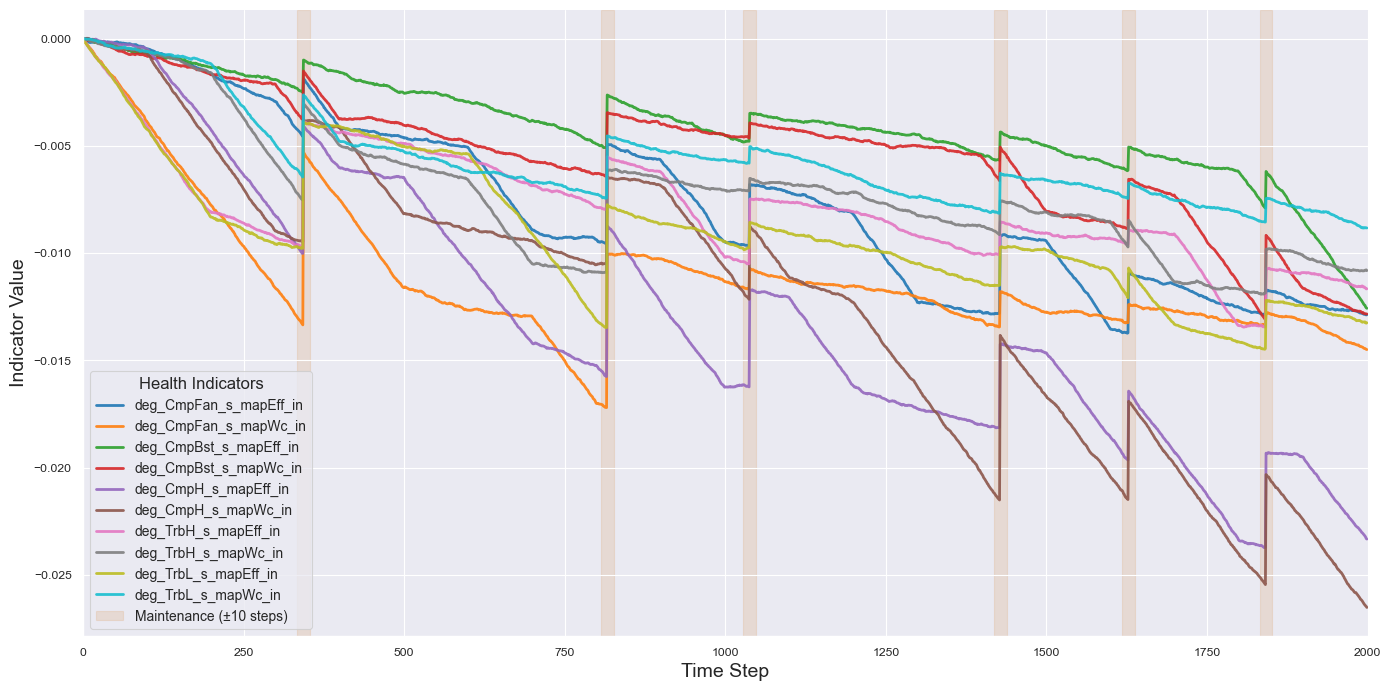

In [45]:
plot_trajectory_seaborn(trajectory, maintenance)

### Plot the sensor measurements (Inputs)

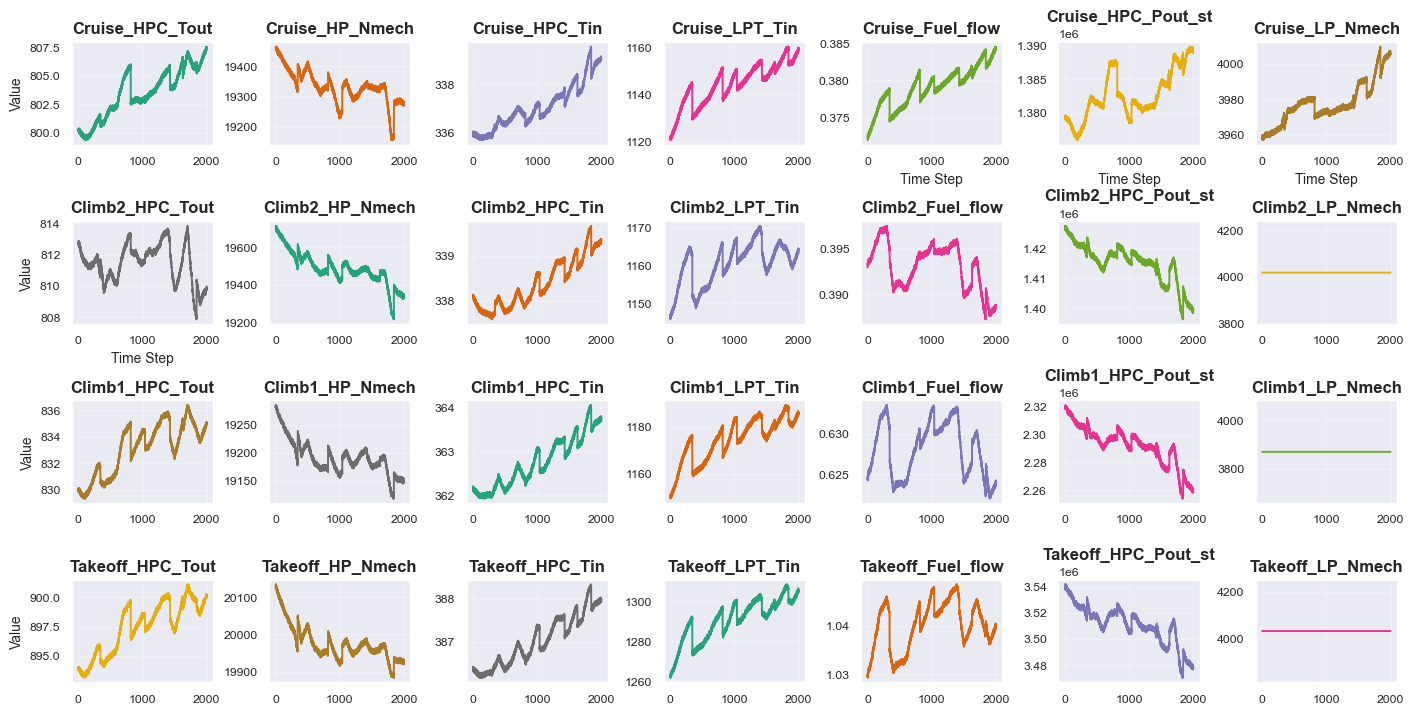

In [62]:
plot_measures_seaborn(sensors, input_features)

### Plot the distribution of inputs and outputs

Scale the inputs for distribution

In [8]:
scaler = MinMaxScaler()
scaled_inputs = scaler.fit_transform(inputs)

In [9]:
# Build a DataFrame from your data and labels
df = pd.DataFrame(scaled_inputs, columns=input_features)

# Split labels into phase and variable (phase = Cruise/Takeoff/Climb1/Climb2)
# variable = HPC_Tout, HP_Nmech, etc.
phase, var = zip(*[lbl.split("_", 1) for lbl in input_features])
phase = list(phase)
var = list(var)

# Melt to long-form for seaborn
long_df = df.melt(var_name="label", value_name="value")
long_df["phase"] = long_df["label"].map({l: p for l, p in zip(input_features, phase)})
long_df["variable"] = long_df["label"].map({l: v for l, v in zip(input_features, var)})

# Optional: impose a consistent order
phase_order = ["Cruise", "Takeoff", "Climb1", "Climb2"]  # tweak if needed
variable_order = sorted(set(var), key=lambda s: (s.split("_")[0], s))  # or define your own list

In [ ]:
plot_measures_distribution(long_df, variable_order=variable_order, phase_order=phase_order)

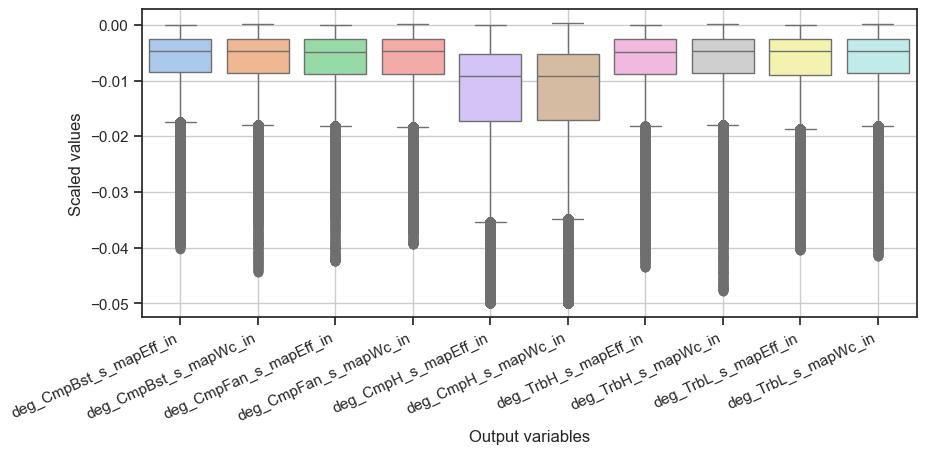

In [8]:
plot_indicators_distribution(df, output_features)